In [2]:
# https://chatgpt.com/share/69ddb42f-080c-83e8-9a98-d8582343dae1

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay


import numpy as np
import matplotlib.pyplot as plt

0.9333333333333333


[Text(0.4, 0.8333333333333334, 'petal length (cm) <= 2.45\ngini = 0.664\nsamples = 120\nvalue = [44, 40, 36]\nclass = y[0]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 44\nvalue = [44, 0, 0]\nclass = y[0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\ngini = 0.499\nsamples = 76\nvalue = [0, 40, 36]\nclass = y[1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.133\nsamples = 42\nvalue = [0, 39, 3]\nclass = y[1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.057\nsamples = 34\nvalue = [0, 1, 33]\nclass = y[2]')]

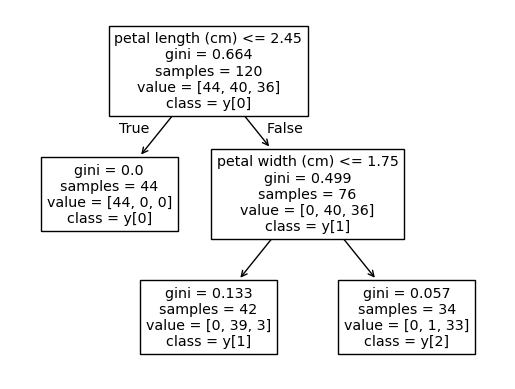

In [4]:
# Train the iris classifier from scratch
# Load iris, select only petal length and petal width, fit DecisionTreeClassifier(max_depth=2, random_state=42), and inspect the fitted tree. This locks in the basic workflow.

iris = load_iris()

train_data, test_data, train_target, test_target = train_test_split(
    iris["data"], iris["target"], test_size=0.2, random_state=22
)

# Select petal length & petal width
train_data = train_data[:, 2:4]
test_data = test_data[:, 2:4]

model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(train_data, train_target)

predicted_target = model.predict(test_data)

accuracy = accuracy_score(test_target, predicted_target)
print(accuracy)

plot_tree(model, feature_names=iris.feature_names[2:4], class_names=True)

In [5]:
print(train_data.shape) #Rows X Columns


(120, 2)


In [6]:
# Visualize the tree using Graphviz
# Export the model with export_graphviz() and render it with graphviz.Source.from_file(). Make sure you can explain every node: gini, samples, value, and class.

# 1. not important

# GINI
# GINI impurity is: If you RANDOMLY pick a input from sample and RANDOMLY label it some class according to the class distribution at that node, how often would you be wrong?
# it involved joing probability. it involves 1-P(a)^2-P(b)^2, where P(a)^2+P(b)^2 is probability of randomly selected element is correct: which further comes from P(a)^2 which means probability of A being selected AND correct: this is joing probability

# why is GINI: ie probability of randomly selected a input as random class: makes a good cost function? with the aim to minimize it.
# if we create a dicision tree which is having minimum gini for every node, 

# Samples: means how many test data points reached the node
# value is array that tells how many data points where either of the given class/category
# class: Majority class at that node (used for prediction)

#How is threshold decided for each decision block in 
# Feature values:
# [2, 4, 7, 10]
# Candidate thresholds:
# 3.0
# 5.5
# 8.5



In [7]:
# Manually trace predictions
# Take a sample like [5, 1.5] and walk through the decision path node by node. Then compare your manual reasoning with predict() and predict_proba()

display(model.predict([[5,1.5]]))
model.predict_proba([[5, 1.5]])

array([1])

array([[0.        , 0.92857143, 0.07142857]])

In [8]:
# Compute Gini impurity by hand
# For the depth-2 left node, calculate Gini using the class counts shown in the tree. Then do the same for entropy and compare the values.

# do the whole process in statquest
# will do later

#How is threshold decided for each decision block in 
# Feature values:
# [2, 4, 7, 10]
# Candidate thresholds:
# 3.0
# 5.5
# 8.5

# t=3

# supposing y:
# those who are A
# x1
# those who are B
# x2, x3, x4

# P(select input x and x is A) = P(selecting input x). P(selected is A)


0.9333333333333333


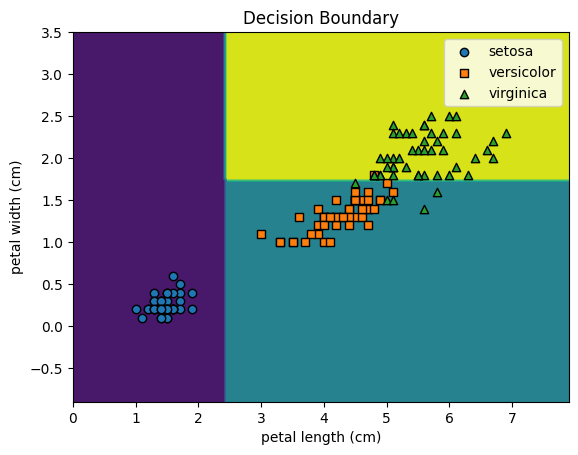

In [9]:
# Important
# Inspect decision boundaries
# Plot the classification regions and understand how max_depth changes the boundary. Repeat with max_depth=3 and compare the geometry.
iris = load_iris()

full_data = iris["data"]
full_target = iris["target"]

train_data, test_data, train_target, test_target = train_test_split(
    iris["data"], iris["target"], test_size=0.2, random_state=22
)

# Select petal length & petal width
train_data = train_data[:, 2:4]
test_data = test_data[:, 2:4]

model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(train_data, train_target)

predicted_target = model.predict(test_data)

accuracy = accuracy_score(test_target, predicted_target)
print(accuracy)

DecisionBoundaryDisplay.from_estimator(
    model,
    train_data,
    response_method="predict",
    # cmap=plt.cm.Pastel2,
    # alpha=0.3,
)

# overlay points
for cls, marker in zip(np.unique(full_target), ["o", "s", "^"]):
    mask = full_target == cls
    plt.scatter(
        full_data[mask, 2],
        full_data[mask, 3],
        marker=marker,
        label=iris.target_names[int(cls)],
        edgecolor="k",
    )

plt.legend()
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("Decision Boundary")
plt.show()

0.9333333333333333


[Text(0.4, 0.8333333333333334, 'petal length (cm) <= 2.45\nentropy = 1.58\nsamples = 120\nvalue = [44, 40, 36]\nclass = y[0]'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 44\nvalue = [44, 0, 0]\nclass = y[0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\nentropy = 0.998\nsamples = 76\nvalue = [0, 40, 36]\nclass = y[1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.371\nsamples = 42\nvalue = [0, 39, 3]\nclass = y[1]'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.191\nsamples = 34\nvalue = [0, 1, 33]\nclass = y[2]')]

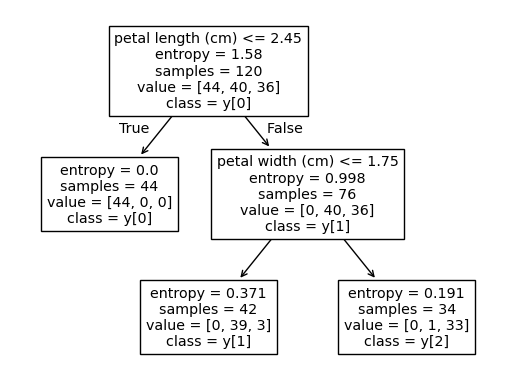

In [10]:
#fluf
# Compare Gini and entropy
# Train two trees on the same iris data: one with default Gini and one with criterion="entropy". Compare the tree shape and the training output.



iris = load_iris()

train_data, test_data, train_target, test_target = train_test_split(
    iris["data"], iris["target"], test_size=0.2, random_state=22
)

# Select petal length & petal width
train_data = train_data[:, 2:4]
test_data = test_data[:, 2:4]

model = DecisionTreeClassifier(criterion="entropy", max_depth=2, random_state=42)
model.fit(train_data, train_target)

predicted_target = model.predict(test_data)

accuracy = accuracy_score(test_target, predicted_target)
print(accuracy)

plot_tree(model, feature_names=iris.feature_names[2:4], class_names=True)

In [11]:
# https://chatgpt.com/share/69ddb42f-080c-83e8-9a98-d8582343dae1

In [12]:
# ============================================================
# NOT YET ATTEMPTED
# ============================================================

# 4. Compute Gini impurity by hand
# For the depth-2 left node, calculate Gini using the class counts shown in the tree. Then do the same for entropy and compare the values.

# 7. Test regularization on moons data
# Generate make_moons(n_samples=150, noise=0.2, random_state=42), train one unrestricted tree and one with min_samples_leaf=5, then compare the decision boundaries and test accuracy.

# 8. Experiment with tree hyperparameters
# Change max_depth, max_leaf_nodes, min_samples_split, min_samples_leaf, max_features, and ccp_alpha. Observe which ones reduce overfitting the most on the moons dataset.

# 9. Build the regression tree example
# Recreate the noisy quadratic dataset using NumPy and fit DecisionTreeRegressor(max_depth=2, random_state=42). Check that each leaf predicts the average target value in that region.

# 10. Increase regression depth and compare
# Fit the same regression tree with max_depth=3 and compare the step-like predictions. Notice how deeper trees fit the noise more aggressively.

# 11. Verify regression MSE split logic
# For a small subset, compute the CART regression objective manually and confirm that the split minimizes weighted MSE.

# 12. Study axis orientation sensitivity
# Rotate or reshape a simple separable dataset and observe how the tree becomes less elegant when the axes are not aligned. This is one of the main limitations of decision trees.

# 13. Add scaling + PCA before the tree
# Build a pipeline with StandardScaler() and PCA(), then fit a tree on the transformed iris data. Compare this boundary with the unrotated version.

# 14. Check native missing-value handling
# Note that DecisionTreeClassifier and DecisionTreeRegressor support missing values natively, so no imputer is required for this model family.

# 15. Reproduce the chapter exercises
# Solve the depth, complexity, overfitting, and scaling questions, then implement the moons-grid-search exercise and the small random-forest-from-trees exercise. Those two are the best end-to-end revision tasks in the chapter.

0.8947368421052632

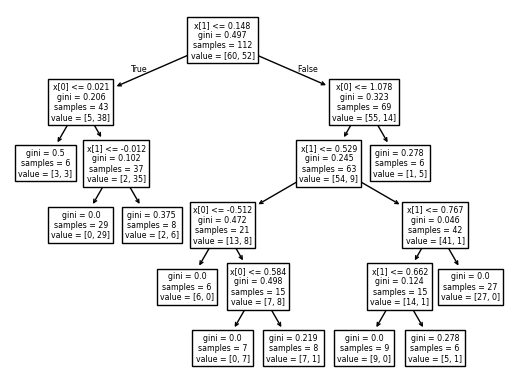

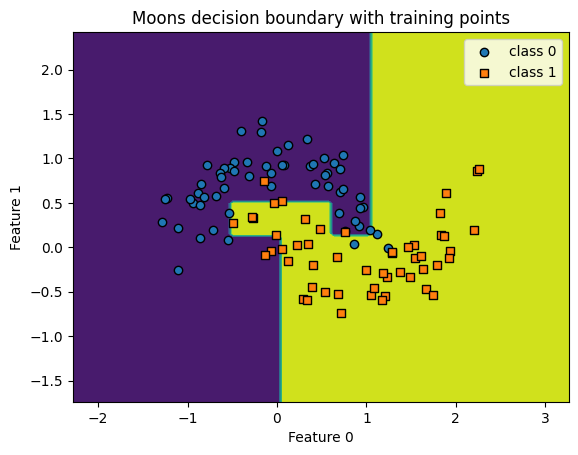

In [59]:
# 7. Test regularization on moons data
# Generate make_moons(n_samples=150, noise=0.2, random_state=42), train one unrestricted tree and one with min_samples_leaf=5, then compare the decision boundaries and test accuracy.


from sklearn.datasets import make_moons

data = make_moons(n_samples=150, noise=0.2, random_state=42)

X = data[0]
y = data[1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=34)


model = DecisionTreeClassifier(random_state=42, min_samples_leaf=6)
model.fit(X_train, y_train)

predicted_target = model.predict(X_test)

display(accuracy_score(y_test, predicted_target))
plot_tree(model)
DecisionBoundaryDisplay.from_estimator(
    model,
    X_train,
    response_method="predict",
    # cmap=plt.cm.Pastel2,
    # alpha=0.3,
)

for cls, marker in zip(np.unique(y_train), ["o", "s"]):
    mask = y_train == cls
    plt.scatter(
        X_train[mask, 0],
        X_train[mask, 1],
        marker=marker,
        label=f"class {int(cls)}",
        edgecolor="k",
    )

plt.legend()
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Moons decision boundary with training points")
plt.show()

# WITH REGULARIZAITON: 81 WITH REGULARIZATION: 90
# THIS IS NOT COMPLETELY CORRECT FOR THIS CASE, WHENE THE RANDOM STATE WAS NOT SOME PARTICULAR STATE: IT WAS GIVING HIGHER NUMBER FOR WITHOUT REGULARIZATION THEN FOR WITH REGULARIZATION



In [48]:
# min_sample_leaf is every leaf must contain at least 5 training examples. that is Each leaf contains some subset of the training data. that minimum should be {defined value}


# how does min_sample_leaf helps in regularization?
    # Why Decision Trees Overfit
    # A decision tree recursively partitions the feature space into smaller and smaller regions.
    # With no constraints, the tree can continue splitting until leaves contain a single sample.
    # That produces rules like:
        # “If income > 73,421 and age < 31.5 and ZIP code = 15213, predict class A.”
    # Such rules often fit noise rather than signal.

In [60]:

# 8. Experiment with tree hyperparameters
# Change max_depth, max_leaf_nodes, min_samples_split, min_samples_leaf, max_features, and ccp_alpha. Observe which ones reduce overfitting the most on the moons dataset.


In [ ]:
# 11. Verify regression MSE split logic
# For a small subset, compute the CART regression objective manually and confirm that the split minimizes weighted MSE.

